# Import libraries

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve
from sklearn.decomposition import PCA
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# Load the dataset

In [36]:
# Specify the file path
file_path = "E:\\reviews.csv"

# Load the CSV file into a DataFrame
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading file: {e}")
    

# Display the first few rows of the DataFrame
data.head()

Data loaded successfully!


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [37]:
if 'text' not in data.columns or 'stars' not in data.columns:
    raise ValueError("The dataset must have 'text' and 'stars' columns!")

# Filter relevant columns
reviews = data[['text', 'stars']]

# Categorize sentiment

In [39]:

def categorize_sentiment(stars):
    if stars >= 4:  # Positive sentiment
        return 'Positive'
    elif stars <= 2:  # Negative sentiment
        return 'Negative'
    else:  # Neutral sentiment
        return 'Neutral'

# Apply the function to create a new 'sentiment' column
reviews.loc[:, 'sentiment'] = reviews['stars'].apply(categorize_sentiment)

# Display the first few rows to confirm
print("\nDataset with Sentiment Labels:")
print(reviews[['text', 'stars', 'sentiment']].head())

# Check the distribution of sentiment labels
print("\nSentiment Distribution:")
print(reviews['sentiment'].value_counts())


Dataset with Sentiment Labels:
                                                text  stars sentiment
0  If you decide to eat here, just be aware it is...      3   Neutral
1  I've taken a lot of spin classes over the year...      5  Positive
2  Family diner. Had the buffet. Eclectic assortm...      3   Neutral
3  Wow!  Yummy, different,  delicious.   Our favo...      5  Positive
4  Cute interior and owner (?) gave us tour of up...      4  Positive

Sentiment Distribution:
sentiment
Positive    343322
Negative    104089
Neutral      52589
Name: count, dtype: int64


# Clean text data

In [41]:
import re
from nltk.corpus import stopwords

# Clean Text Data (Including Negation Handling)
def clean_text(text):
    # Handle negation patterns
    negation_patterns = [
        (r'\b(not|no|never|nothing|nowhere|none|nobody)\s+(\w+)', r'\1_\2'),
        (r'\b(cannot)\b', 'can_not'),
        (r'\b(ain\'t|aren\'t|don\'t|doesn\'t|didn\'t)\b', 'not'),
        (r'\b(isn\'t|wasn\'t|weren\'t|haven\'t|hasn\'t|hadn\'t)\b', 'not')
    ]
    
    for pattern, replacement in negation_patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

stop_words = set(stopwords.words('english'))
reviews.loc[:, 'cleaned_text'] = reviews['text'].apply(clean_text)

# Display the first few rows to confirm cleaning
print("\nCleaned Text Data:")
print(reviews[['text', 'cleaned_text']].head())


Cleaned Text Data:
                                                text  \
0  If you decide to eat here, just be aware it is...   
1  I've taken a lot of spin classes over the year...   
2  Family diner. Had the buffet. Eclectic assortm...   
3  Wow!  Yummy, different,  delicious.   Our favo...   
4  Cute interior and owner (?) gave us tour of up...   

                                        cleaned_text  
0  decide eat aware going take hours beginning en...  
1  ive taken lot spin classes years nothingcompar...  
2  family diner buffet eclectic assortment large ...  
3  wow yummy different delicious favorite lamb cu...  
4  cute interior owner gave us tour upcoming pati...  


# Split the data into training and testing sets

In [42]:
from sklearn.model_selection import train_test_split

# Features (text data) and Labels (sentiment)
X = reviews['cleaned_text']  # Features: cleaned text
y = reviews['sentiment']     # Labels: sentiment

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reduce training set to 50,000 and testing set to 5,000
X_train = X_train[:5000]
y_train = y_train[:5000]
X_test = X_test[:500]
y_test = y_test[:500]

# Display the size of the splits
print("\nData Split Completed:")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Data Split Completed:
Training set size: 5000
Testing set size: 500


# Initialize CountVectorizer (Unigrams only)

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer (Unigrams only)
count_vectorizer = CountVectorizer(ngram_range=(1, 1))  # Unigrams only

# Fit and transform the training data
X_train_count = count_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_count = count_vectorizer.transform(X_test)

# Print the shape to confirm the transformation
print("\nCount Vectorized Data (Unigrams) Shape:")
print(f"Training data shape: {X_train_count.shape}")
print(f"Testing data shape: {X_test_count.shape}")


Count Vectorized Data (Unigrams) Shape:
Training data shape: (5000, 20915)
Testing data shape: (500, 20915)


# Initialize TF-IDF Vectorizer (Unigrams + Bigrams)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer (Unigrams + Bigrams)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Print the shape to confirm the transformation
print("\nTF-IDF Vectorized Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")


TF-IDF Vectorized Data (Unigrams + Bigrams) Shape:
Training data shape: (5000, 208729)
Testing data shape: (500, 208729)


# Apply One-Hot Encoding to training and testing data

In [45]:
from sklearn.preprocessing import MultiLabelBinarizer

# Function to apply One-Hot Encoding
def one_hot_encode(text_data):
    # Create a bag of words (unigrams and bigrams)
    vectorizer = CountVectorizer(ngram_range=(1, 2))
    # Fit the vectorizer and transform the text data
    X_one_hot = vectorizer.fit_transform(text_data)
    return X_one_hot, vectorizer

# Apply One-Hot Encoding to training and testing data
X_train_one_hot, vectorizer = one_hot_encode(X_train)
X_test_one_hot = vectorizer.transform(X_test)

# Print the shape of the One-Hot Encoded data
print("\nOne-Hot Encoded Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_one_hot.shape}")
print(f"Testing data shape: {X_test_one_hot.shape}")


One-Hot Encoded Data (Unigrams + Bigrams) Shape:
Training data shape: (5000, 208729)
Testing data shape: (500, 208729)


# Apply TF-IDF Vectorization (Unigrams + Bigrams)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Apply TF-IDF Vectorization (Unigrams + Bigrams)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Define a threshold for TF-IDF values (e.g., 0.1) to binarize the matrix
threshold = 0.1

# Binarize the TF-IDF matrix (One-Hot-like Encoding)
X_train_bin = (X_train_tfidf > threshold).astype(int)
X_test_bin = (X_test_tfidf > threshold).astype(int)

# Print the shape of the One-Hot-like Encoded data
print("\nOne-Hot-like Encoded Data (TF-IDF with Threshold) Shape:")
print(f"Training data shape: {X_train_bin.shape}")
print(f"Testing data shape: {X_test_bin.shape}")


One-Hot-like Encoded Data (TF-IDF with Threshold) Shape:
Training data shape: (5000, 208729)
Testing data shape: (500, 208729)


# Initialize the Naive Bayes model

In [47]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Initialize the Naive Bayes model
nb_model_count = MultinomialNB()

# Train the Naive Bayes model on Count Vectorized data (Unigrams)
nb_model_count.fit(X_train_count, y_train)

# Make predictions on the test data
y_pred_count = nb_model_count.predict(X_test_count)

# Evaluate the model
print("Naive Bayes with Count Vectorization (Unigrams):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_count)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_count))
print("Classification Report:")
print(classification_report(y_test, y_pred_count))
print(f"AUC: {roc_auc_score(y_test, nb_model_count.predict_proba(X_test_count), multi_class='ovr')}")

Naive Bayes with Count Vectorization (Unigrams):
Accuracy: 0.84
Confusion Matrix:
[[ 80   1  31]
 [  5   3  34]
 [  8   1 337]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.71      0.78       112
     Neutral       0.60      0.07      0.13        42
    Positive       0.84      0.97      0.90       346

    accuracy                           0.84       500
   macro avg       0.77      0.59      0.60       500
weighted avg       0.82      0.84      0.81       500

AUC: 0.8400497999022836


# Initialize the Naive Bayes model for TF-IDF data

In [48]:
# Initialize the Naive Bayes model for TF-IDF data
nb_model_tfidf = MultinomialNB()

# Train the Naive Bayes model on TF-IDF Vectorized data (Unigrams + Bigrams)
nb_model_tfidf.fit(X_train_tfidf, y_train)

# Make predictions on the test data
y_pred_tfidf_nb = nb_model_tfidf.predict(X_test_tfidf)

# Evaluate the model
print("Naive Bayes with TF-IDF Vectorization (Unigrams + Bigrams):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf_nb)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf_nb))
print("Classification Report:")
print(classification_report(y_test, y_pred_tfidf_nb))
print(f"AUC: {roc_auc_score(y_test, nb_model_tfidf.predict_proba(X_test_tfidf), multi_class='ovr')}")


Naive Bayes with TF-IDF Vectorization (Unigrams + Bigrams):
Accuracy: 0.692
Confusion Matrix:
[[  0   0 112]
 [  0   0  42]
 [  0   0 346]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       112
     Neutral       0.00      0.00      0.00        42
    Positive       0.69      1.00      0.82       346

    accuracy                           0.69       500
   macro avg       0.23      0.33      0.27       500
weighted avg       0.48      0.69      0.57       500

AUC: 0.7569002441822793


E:\New folder\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\New folder\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\New folder\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Initialize the Naive Bayes model for One-Hot encoded TF-IDF data

In [49]:
# Initialize the Naive Bayes model for One-Hot encoded TF-IDF data
nb_model_one_hot_tfidf = MultinomialNB()

# Train the Naive Bayes model on One-Hot encoded TF-IDF data
nb_model_one_hot_tfidf.fit(X_train_bin, y_train)

# Make predictions on the test data
y_pred_bin_tfidf = nb_model_one_hot_tfidf.predict(X_test_bin)

# Evaluate the model
print("Naive Bayes with One-Hot Encoding of TF-IDF:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bin_tfidf)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bin_tfidf))
print("Classification Report:")
print(classification_report(y_test, y_pred_bin_tfidf))
print(f"AUC: {roc_auc_score(y_test, nb_model_one_hot_tfidf.predict_proba(X_test_bin), multi_class='ovr')}")


Naive Bayes with One-Hot Encoding of TF-IDF:
Accuracy: 0.76
Confusion Matrix:
[[ 35   0  77]
 [  2   1  39]
 [  1   1 344]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.31      0.47       112
     Neutral       0.50      0.02      0.05        42
    Positive       0.75      0.99      0.85       346

    accuracy                           0.76       500
   macro avg       0.72      0.44      0.46       500
weighted avg       0.77      0.76      0.70       500

AUC: 0.8317805426312764


# Initialize the SVM model

In [50]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model_tfidf = SVC(kernel='linear', probability=True)

# Train the SVM model on TF-IDF Vectorized data (Unigrams + Bigrams)
svm_model_tfidf.fit(X_train_tfidf, y_train)

# Make predictions on the test data
y_pred_tfidf = svm_model_tfidf.predict(X_test_tfidf)

# Evaluate the model
print("SVM with TF-IDF Vectorization (Unigrams + Bigrams):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))
print("Classification Report:")
print(classification_report(y_test, y_pred_tfidf))
print(f"AUC: {roc_auc_score(y_test, svm_model_tfidf.predict_proba(X_test_tfidf), multi_class='ovr')}")

SVM with TF-IDF Vectorization (Unigrams + Bigrams):
Accuracy: 0.854
Confusion Matrix:
[[ 84   4  24]
 [  6   6  30]
 [  5   4 337]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.75      0.81       112
     Neutral       0.43      0.14      0.21        42
    Positive       0.86      0.97      0.91       346

    accuracy                           0.85       500
   macro avg       0.72      0.62      0.65       500
weighted avg       0.83      0.85      0.83       500

AUC: 0.9315238762550632


#  SVM model on Count Vectorized data (Unigrams + Bigrams)

In [51]:
# Initialize the SVM model for Count Vectorized data (Unigrams + Bigrams)
svm_model_count = SVC(kernel='linear', probability=True)

# Train the SVM model on Count Vectorized data (Unigrams + Bigrams)
svm_model_count.fit(X_train_count, y_train)

# Make predictions on the test data
y_pred_count_svm = svm_model_count.predict(X_test_count)

# Evaluate the model
print("SVM with Count Vectorization (Unigrams + Bigrams):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_count_svm)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_count_svm))
print("Classification Report:")
print(classification_report(y_test, y_pred_count_svm))
print(f"AUC: {roc_auc_score(y_test, svm_model_count.predict_proba(X_test_count), multi_class='ovr')}")


SVM with Count Vectorization (Unigrams + Bigrams):
Accuracy: 0.822
Confusion Matrix:
[[ 83  11  18]
 [  9  11  22]
 [ 11  18 317]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.74      0.77       112
     Neutral       0.28      0.26      0.27        42
    Positive       0.89      0.92      0.90       346

    accuracy                           0.82       500
   macro avg       0.66      0.64      0.65       500
weighted avg       0.82      0.82      0.82       500

AUC: 0.8825832636055656


# Hyperparameter grid for SVM

In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
}

# Initialize SVM model
svm = SVC()

# Perform Grid Search
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train_tfidf, y_train)

# Best parameters found
print("Best Parameters: ", grid_search.best_params_)

# Best model performance
best_model = grid_search.best_estimator_
print("Best Model Accuracy: ", best_model.score(X_test_tfidf, y_test))


Best Parameters:  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Model Accuracy:  0.852


In [53]:
# Feature Importance Analysis for Naive Bayes
def show_top_features(model, vectorizer, class_idx=0, n=10):
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.feature_log_prob_[class_idx]
    top_features = sorted(zip(coefs, feature_names), reverse=True)[:n]
    print(f"\nTop features for class {model.classes_[class_idx]}:")
    for coef, feat in top_features:
        print(f"{feat}: {np.exp(coef):.4f}")

show_top_features(nb_model_count, count_vectorizer, class_idx=0)  # Negative class
show_top_features(nb_model_count, count_vectorizer, class_idx=2)  # Positive class


Top features for class Negative:
food: 0.0072
would: 0.0058
place: 0.0056
service: 0.0051
like: 0.0051
time: 0.0049
get: 0.0049
back: 0.0049
one: 0.0040
order: 0.0038

Top features for class Positive:
great: 0.0107
good: 0.0089
place: 0.0087
food: 0.0087
service: 0.0054
time: 0.0051
like: 0.0047
one: 0.0047
get: 0.0047
back: 0.0045


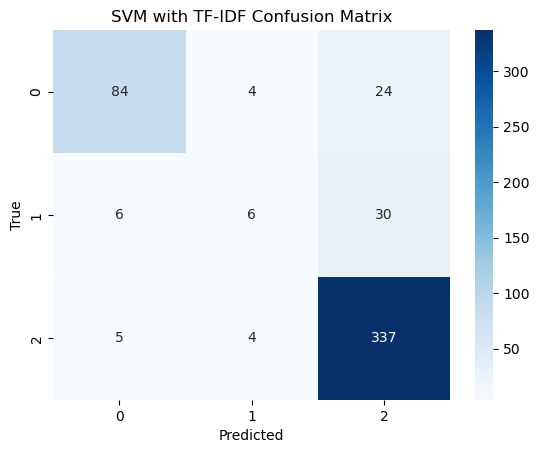

In [54]:
# Confusion Matrix Heatmap
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_confusion_matrix(y_test, y_pred_tfidf, "SVM with TF-IDF Confusion Matrix")

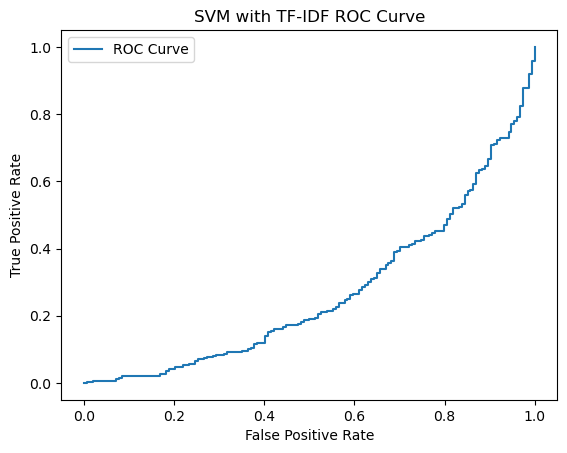

In [55]:
# ROC Curve
def plot_roc_curve(y_true, y_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1], pos_label='Positive')
    plt.plot(fpr, tpr, label='ROC Curve')
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

plot_roc_curve(y_test, svm_model_tfidf.predict_proba(X_test_tfidf), "SVM with TF-IDF ROC Curve")